# UNIVERSIDAD POLITECNICA SALESIANA
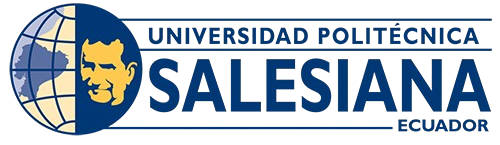

---
**Desarrollado por:**
 Karen Ortiz - Andrés Encalada - Erika Contreras - Jorge Pizarro

# FASE 1: Análisis y preparación del dataset.

## Preparación del entorno

In [1]:
import tf2onnx
import onnx
import keras_tuner as kt
import onnxruntime as ort
import xgboost as xgb
import onnxmltools
from onnxmltools.convert.common.data_types import FloatTensorType
import skl2onnx
from skl2onnx import to_onnx
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

In [2]:
import datetime
import seaborn as sns
import holidays
import pandas as pd
import numpy as np
import joblib
from keras.optimizers import Adam
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from pandas import read_csv
import tensorflow as tf
from keras.models import Model
from keras.layers import LSTM, Dense, Dropout, Input
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.interpolate import make_interp_spline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from IPython.display import display, HTML

In [3]:
csv1_path= '../data_sample/productos.csv'
csv2_path= '../data_sample/ventas.csv'

## Descripción del dataset

Los datasets cargados fueron obtenidos de Kaggle ("Datasets para Proyecto BI - Análisis de Ventas"). El dataset de productos detalla el inventario del negocio, contando con 5 variables y 38 variables. El dataset de ventas detalla las ventas realizadas en el negocio, contando con 7 variables y 3029 registros.

El dataset de productos será usado en un futuro para identificar los productos por su ID, por ahora solo se lo analiza para observar los datos.

## Análisis y preparación de los datos de ventas

### Analisis textual

In [42]:
df=read_csv(csv2_path)
df.head()

,ID_Venta,Fecha,ID_Cliente,ID_Producto,Cantidad,Método_Pago,Estado
0,919,31/01/2024,10,25,5,1,Completa
1,947,31/01/2024,106,5,1,4,Completa
2,1317,31/1/2024,235,25,3,3,Completa
3,1607,31/1/2024,114,15,5,1,Completa
4,2038,31/1/2024,132,2,5,4,Completa


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3029 entries, 0 to 3028
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID_Venta     3029 non-null   int64 
 1   Fecha        3029 non-null   object
 2   ID_Cliente   3029 non-null   int64 
 3   ID_Producto  3029 non-null   int64 
 4   Cantidad     3029 non-null   int64 
 5   Método_Pago  3029 non-null   int64 
 6   Estado       3029 non-null   object
dtypes: int64(5), object(2)
memory usage: 165.8+ KB


In [10]:
df.describe().round()

,ID_Venta,ID_Cliente,ID_Producto,Cantidad,Método_Pago
count,3029.0,3029.0,3029.0,3029.0,3029.0
mean,1493.0,162.0,20.0,3.0,3.0
std,866.0,94.0,11.0,2.0,1.0
min,1.0,1.0,1.0,1.0,1.0
25%,729.0,79.0,10.0,2.0,2.0
50%,1486.0,162.0,20.0,3.0,4.0
75%,2243.0,243.0,29.0,5.0,5.0
max,3000.0,326.0,38.0,6.0,5.0


---
### Inyección de datos

Vamos a contar la cantidad de transacciones completadas con exito.

In [43]:
df['Estado'].value_counts()

Estado
Completa     2548
Pendiente     471
Cancelada      10
Name: count, dtype: int64

Observamos que solamente 2548 transacciones fueron completadas correctamente, procederemos a eliminar el resto

In [44]:
df=df[df['Estado']=='Completa']

Debemos tomar en cuenta que el dataset incluye solamente las fechas en las que se realizaron compras, no incluye fechas que no tengan ventas, por lo que procederemos a crear estas filas con valor de venta igual a 0.

In [45]:
#Creamos una copia para dejar el original intacto y hacer comparaciones en el futuro
df_completo= df.copy()
#Creamos la columna fecha_venta, en formato datetime
df_completo['Fecha_Venta'] = pd.to_datetime(df_completo['Fecha'], dayfirst=True)
df_completo.drop(['Fecha'], axis=1, inplace=True)

#Sumamos ventas del mismo producto en un mismo día, debido a que no nos interesa separar las ventas por cliente
df_completo=df_completo.groupby(['Fecha_Venta', 'ID_Producto'])['Cantidad'].sum().reset_index()

#Establecemos el limite de fechas para el relleno
fecha_min=df_completo['Fecha_Venta'].min()
fecha_max=df_completo['Fecha_Venta'].max()
#Creamos todas las fechas posibles dentro del rango establecido
rango_f= pd.date_range(start=fecha_min, end=fecha_max)
productos=df_completo['ID_Producto'].unique()
idx_completo=pd.MultiIndex.from_product([rango_f,productos],names=['Fecha_Venta', 'ID_Producto'])
df_ventas=pd.DataFrame(index=idx_completo).reset_index()

#Unimos a las ventas ya registradas del dataset original
df_completo=pd.merge(df_ventas, df_completo, on=['Fecha_Venta','ID_Producto'],how='left')
#Rellenamos todos estos datos nulos con 0
df_completo['Cantidad']=df_completo['Cantidad'].fillna(0)

df_completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12730 entries, 0 to 12729
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Fecha_Venta  12730 non-null  datetime64[ns]
 1   ID_Producto  12730 non-null  int64         
 2   Cantidad     12730 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 298.5 KB


Hemos pasado de 2548 datos (Transacciones completas) a 12730, por lo que tenemos más de diez mil datos en 0, para evitar que el modelo nos otorgue predicciones de 0 o 1 siempre, insertaremos datos al conjunto de manera razonable y no al azar, insertando más ventas en días en los que la gente suele recibir su pago y en los fines de semana.

In [ ]:
def generar_ventas(row):
    id_prod = row['ID_Producto']
    fecha = row['Fecha_Venta']
    mes = fecha.month
    dia_semana = fecha.dayofweek  # 0=Lunes, 6=Domingo
    dia_mes = fecha.day
    
    # Pan
    if id_prod == 12:
        volumen = np.random.normal(loc=120, scale=15)
        prob_cero = 0.01
        
    # Lácteos
    elif id_prod in [1, 2]: # Leche, Yogur
        volumen = np.random.normal(loc=40, scale=8)
        prob_cero = 0.02
        
    # Panadería dulce
    elif id_prod in [14, 15]: # Facturas, Medialunas
        volumen = np.random.normal(loc=35, scale=8)
        prob_cero = 0.05
        
    # Bebidas no alcohólicas (Agua, Jugos)
    elif id_prod in [27, 28]:
        volumen = np.random.normal(loc=20, scale=5)
        prob_cero = 0.05
        
    # Cerveza (Comportamiento altamente dependiente del fin de semana)
    elif id_prod == 29: 
        volumen = np.random.normal(loc=25, scale=6)
        prob_cero = 0.05
        
    # Frutas y Verduras
    elif id_prod in [17, 18, 19, 20, 21, 22]: 
        volumen = np.random.normal(loc=15, scale=4)
        prob_cero = 0.05
        
    # Carnes
    elif id_prod in [8, 9, 11]:
        volumen = np.random.normal(loc=12, scale=3)
        prob_cero = 0.05
        
    # Carnes para asado/parrilla
    elif id_prod in [6, 7, 10]:
        volumen = np.random.normal(loc=8, scale=2)
        prob_cero = 0.15
        
    # Despensa básica (Quesos, Manteca, Arroz, Atún)
    elif id_prod in [3, 4, 5, 35, 38]:
        volumen = np.random.normal(loc=10, scale=3)
        prob_cero = 0.05
        
    # Despensa de rotación lenta (Lentejas, Garbanzos)
    elif id_prod in [36, 37]:
        volumen = np.random.normal(loc=4, scale=1.5)
        prob_cero = 0.25
        
    # Snacks y Galletas
    elif id_prod in [31, 32, 33, 34]:
        volumen = np.random.normal(loc=12, scale=4)
        prob_cero = 0.10
        
    # Congelados (Papas fritas, Empanadas, Pizza, Hamburguesas)
    elif id_prod in [23, 24, 25, 26]:
        volumen = np.random.normal(loc=6, scale=2)
        prob_cero = 0.15
        
    # Productos Ocasionales (Vino tinto, Tortas)
    elif id_prod in [16, 30]:
        volumen = np.random.normal(loc=3, scale=1)
        prob_cero = 0.40
        
    else:
        volumen = np.random.normal(loc=10, scale=3)
        prob_cero = 0.10
    if np.random.rand() < prob_cero:
        return 0.0


    mult = 1.0    
    #Quincena y Fin de mes
    if dia_mes in [14, 15, 16, 29, 30, 31]:
        mult *= 1.35 

    #Fin de Semana
    if dia_semana >= 5: 
        if id_prod in [6, 7, 10, 29]: # Asado, Chorizo, Costilla y Cerveza
            mult *= 3.0 
        elif id_prod in [14, 15, 16, 30]: # Facturas, Medialunas, Tortas, Vino
            mult *= 2.0 
        elif id_prod in [23, 24, 25, 26, 31, 32, 33, 34]: # Congelados y Snacks
            mult *= 1.5
        elif id_prod == 12: # Pan sube ligeramente
            mult *= 1.2
    else: # Lunes a Viernes
        if id_prod in [29, 30]: # La venta de alcohol cae entre semana
            mult *= 0.6

    # Diciembre
    if mes == 12:
        if id_prod in [16, 30]:  # Tortas y Vino
            mult *= 2.5
        elif id_prod in [6, 7, 10, 29]: # Parrilla y Cerveza
            mult *= 1.5
            
    # Meses Fríos o Lluviosos
    if mes in [6, 7, 8]:
        if id_prod in [36, 37]:  # Lentejas, Garbanzos (Sopas y guisos)
            mult *= 1.8
        if id_prod in [27, 28, 29]:  # Agua, Jugos, Cerveza (Bebidas frías caen)
            mult *= 0.7
            
    # Meses Cálidos / Vacaciones (Ej. Febrero, Marzo)
    if mes in [2, 3]:
        if id_prod in [27, 28, 29]:  # Bebidas frías suben
            mult *= 1.6

    cantidad_final = volumen * mult
    cantidad_final = max(1.0, cantidad_final)
    # Agregamos "ruido blanco" (un 10% de variación aleatoria extra) 
    # para evitar que los algoritmos de ML encuentren un patrón matemático perfecto
    cantidad_final = cantidad_final + np.random.normal(loc=0, scale=cantidad_final*0.1)
    
    # Retornamos el valor final redondeado, asegurando que sea al menos 1
    return max(1, int(np.round(cantidad_final)))

# Aplicar al dataframe
df_completo['Cantidad'] = df_completo.apply(generar_ventas, axis=1)


In [47]:
#Ahora ordenamos los datos de la forma: Ordenar según productos -> Subordenar segun fechas
df_completo=df_completo.sort_values(by=['ID_Producto','Fecha_Venta']).reset_index(drop=True)

#Establecemos un bucle para crear las ventanas de tiempo, de 7 días anteriores
for i in range(1,8):
  df_completo[f'Cantidad_{i}_dias']=df_completo.groupby(['ID_Producto'])['Cantidad'].shift(i)
#Debido a que las primeras 7 filas no tendrán 7 registros hacia atrás, tendremos valores nulos, eliminaremos esas columnas
df_completo = df_completo.dropna()

In [48]:
df_completo.to_csv('../data/ventasT.csv', index=False)
df_completo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12464 entries, 7 to 12729
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Fecha_Venta      12464 non-null  datetime64[ns]
 1   ID_Producto      12464 non-null  int64         
 2   Cantidad         12464 non-null  float64       
 3   Cantidad_1_dias  12464 non-null  float64       
 4   Cantidad_2_dias  12464 non-null  float64       
 5   Cantidad_3_dias  12464 non-null  float64       
 6   Cantidad_4_dias  12464 non-null  float64       
 7   Cantidad_5_dias  12464 non-null  float64       
 8   Cantidad_6_dias  12464 non-null  float64       
 9   Cantidad_7_dias  12464 non-null  float64       
dtypes: datetime64[ns](1), float64(8), int64(1)
memory usage: 1.0 MB


Ahora disponemos de un dataset de 12464 entradas con datos solidos y razonables a lo largo del año, lo que será de gran ayuda para entrenar un modelo razonable que realice predicciones acertadas

### Análisis Gráfico

In [49]:
df_completo=pd.read_csv('../data/ventasT.csv')
df_completo['Fecha_Venta'] = pd.to_datetime(df_completo['Fecha_Venta'], format='%Y-%m-%d', errors='coerce')
#Creamos una copia para realizar agrupaciones y analisis
df_analisis=df_completo.copy()
#Instanciamos el df de productos para saber los nombres
df_productos=pd.read_csv(csv1_path)

#### **Gráfico 1: Total de ventas y porcentaje del negocio acumulado**

C:\Users\andre\AppData\Local\Temp\ipykernel_28936\1852770197.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_top['Nombre_producto'], rotation=45, ha='right', fontsize=11)


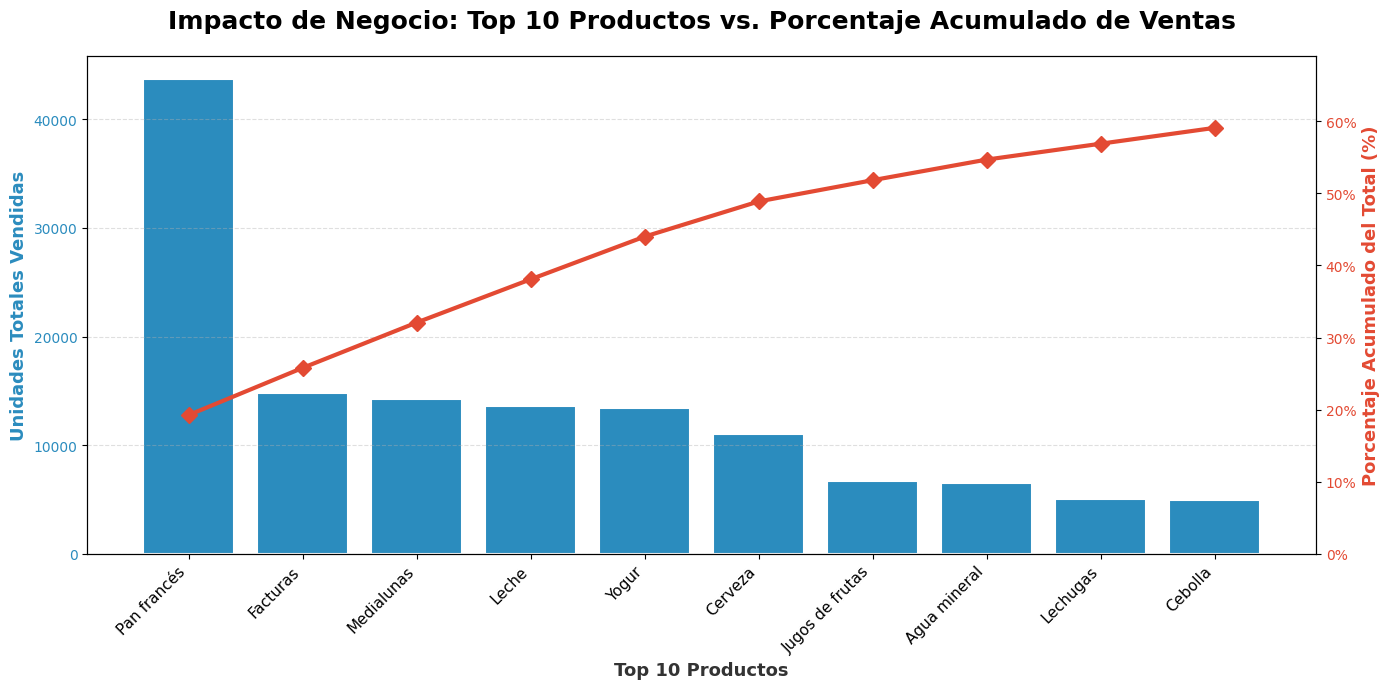

In [50]:
#Agrupar ventas totales por producto y ordenar de mayor a menor
ventas_prod = df_analisis.groupby('ID_Producto')['Cantidad'].sum().reset_index()
ventas_prod = ventas_prod.sort_values(by='Cantidad', ascending=False)

# Merge con nombres reales
ventas_prod = ventas_prod.merge(df_productos[['ID_Producto', 'Nombre_producto']], on='ID_Producto', how='left')
#Calcular el porcentaje que representa cada producto
total_ventas = ventas_prod['Cantidad'].sum()
ventas_prod['Porcentaje'] = (ventas_prod['Cantidad'] / total_ventas) * 100
ventas_prod['Acumulado'] = ventas_prod['Porcentaje'].cumsum()
# Seleccionamos el Top 10
df_top = ventas_prod.head(10).copy()

fig, ax1 = plt.subplots(figsize=(14, 7))
color_barras = '#2b8cbe'
ax1.bar(df_top['Nombre_producto'], df_top['Cantidad'], color=color_barras, edgecolor='white', linewidth=1.5)
ax1.set_xlabel('Top 10 Productos', fontsize=13, fontweight='bold', color='#333333')
ax1.set_ylabel('Unidades Totales Vendidas', fontsize=13, fontweight='bold', color=color_barras)
ax1.tick_params(axis='y', labelcolor=color_barras)
ax1.set_xticklabels(df_top['Nombre_producto'], rotation=45, ha='right', fontsize=11)
ax2 = ax1.twinx()
color_linea = '#e34a33'
ax2.plot(df_top['Nombre_producto'], df_top['Acumulado'], color=color_linea, marker='D', ms=8, linewidth=3, label='Acumulado (%)')
ax2.set_ylabel('Porcentaje Acumulado del Total (%)', fontsize=13, fontweight='bold', color=color_linea)
ax2.tick_params(axis='y', labelcolor=color_linea)
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_ylim(0, df_top['Acumulado'].max() + 10)
plt.title('Impacto de Negocio: Top 10 Productos vs. Porcentaje Acumulado de Ventas', fontsize=18, fontweight='bold', pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

#### **Gráfico 2: Análisis de ventas de toda la semana para el producto más vendido**

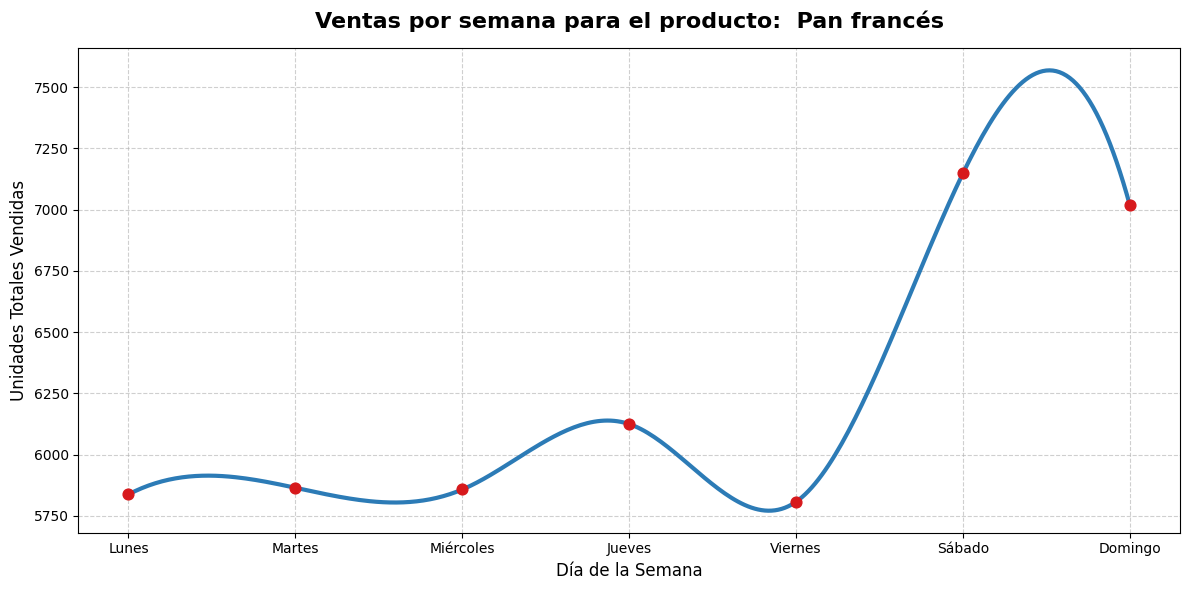

In [51]:
#Obtener el producto más vendido
top_product_id = df_analisis.groupby('ID_Producto')['Cantidad'].sum().sort_values(ascending=False).index[0]
product_name = df_productos[df_productos['ID_Producto'] == top_product_id]['Nombre_producto'].iloc[0]
#Filtrar para dejar solo el producto mas vendido
df_single_product = df_analisis[df_analisis['ID_Producto'] == top_product_id].copy()
df_single_product['Dia_Semana'] = df_single_product['Fecha_Venta'].dt.dayofweek # 0=Lunes, 6=Domingo
#Sumar las ventas por cada dia de la semana
ventas_dia_single = df_single_product.groupby('Dia_Semana')['Cantidad'].sum().reset_index()
ventas_dia_single = ventas_dia_single.sort_values('Dia_Semana')

x = ventas_dia_single['Dia_Semana'].values
y = ventas_dia_single['Cantidad'].values
x_smooth = np.linspace(x.min(), x.max(), 300)
spl = make_interp_spline(x, y, k=3)
y_smooth = spl(x_smooth)
y_smooth = np.clip(y_smooth, 0, None)

dia_nombres = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
plt.figure(figsize=(12, 6))
plt.plot(x_smooth, y_smooth, linewidth=3, color='#2c7bb6')
plt.scatter(x, y, color='#d7191c', s=60, zorder=5, label='Volumen Real Acumulado')
plt.xticks(ticks=range(7), labels=dia_nombres)
plt.title(f'Ventas por semana para el producto:  {product_name}', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Día de la Semana', fontsize=12)
plt.ylabel('Unidades Totales Vendidas', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

#### **Gráfico 3: Ventas del producto más vendido los fines de semana**

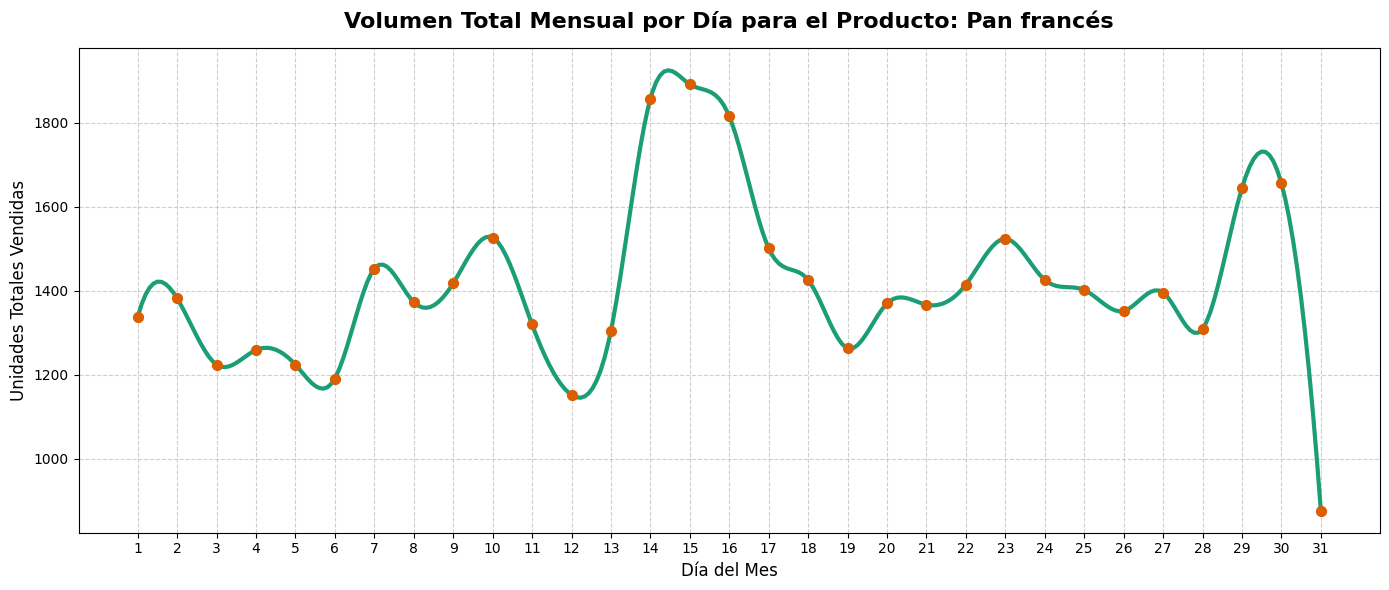

In [52]:
#Obtener el producto más vendido
top_product_id = df_analisis.groupby('ID_Producto')['Cantidad'].sum().sort_values(ascending=False).index[0]
product_name = df_productos[df_productos['ID_Producto'] == top_product_id]['Nombre_producto'].iloc[0]
df_single_product = df_analisis[df_analisis['ID_Producto'] == top_product_id].copy()
df_single_product['Dia_Mes'] = df_single_product['Fecha_Venta'].dt.day
ventas_dia_mes = df_single_product.groupby('Dia_Mes')['Cantidad'].sum().reset_index()
ventas_dia_mes = ventas_dia_mes.sort_values('Dia_Mes')

x_mes = ventas_dia_mes['Dia_Mes'].values
y_mes = ventas_dia_mes['Cantidad'].values
x_mes_smooth = np.linspace(x_mes.min(), x_mes.max(), 300)
spl_mes = make_interp_spline(x_mes, y_mes, k=3)
y_mes_smooth = spl_mes(x_mes_smooth)
y_mes_smooth = np.clip(y_mes_smooth, 0, None)

plt.figure(figsize=(14, 6))
plt.plot(x_mes_smooth, y_mes_smooth, linewidth=3, color='#1b9e77')
plt.scatter(x_mes, y_mes, color='#d95f02', s=50, zorder=5)
plt.xticks(ticks=range(1, 32))
plt.title(f'Volumen Total Mensual por Día para el Producto: {product_name}', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Día del Mes', fontsize=12)
plt.ylabel('Unidades Totales Vendidas', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

#### **Gráfico 4: Análisis de ventas totales a lo largo del año**

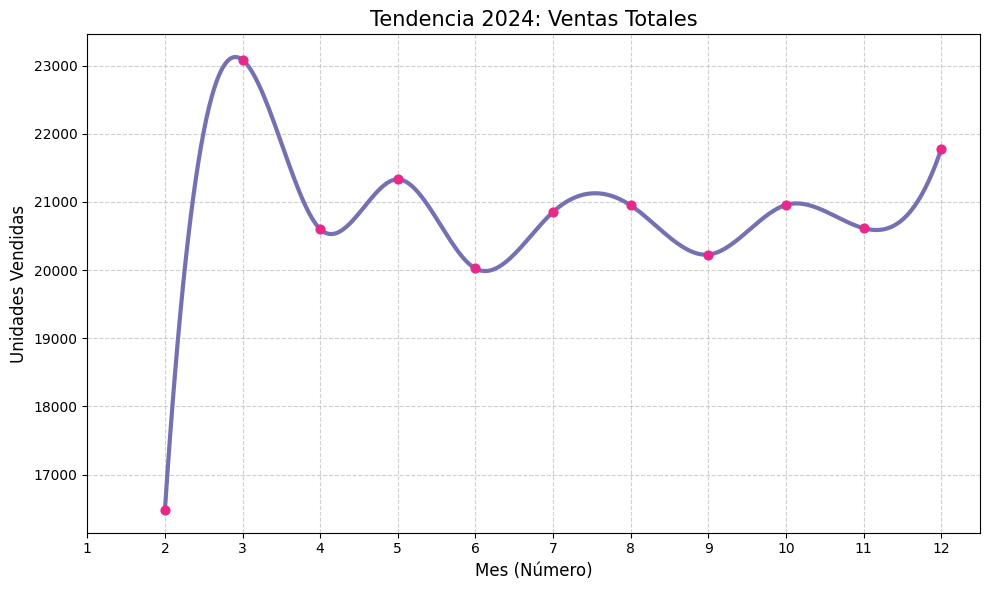

In [53]:
df_analisis['Mes'] = df_analisis['Fecha_Venta'].dt.month
ventas_totales_mes = df_analisis.groupby('Mes')['Cantidad'].sum()

# Extraemos los valores X (meses) y Y (ventas)
x_meses = ventas_totales_mes.index.values
y_meses = ventas_totales_mes.values
# Creamos 300 puntos intermedios entre el primer y ultimo mes registrado
x_meses_smooth = np.linspace(x_meses.min(), x_meses.max(), 300)
# Aplicamos la interpolación cúbica (k=3)
spl_meses = make_interp_spline(x_meses, y_meses, k=3)
y_meses_smooth = spl_meses(x_meses_smooth)

plt.figure(figsize=(10, 6))
plt.plot(x_meses_smooth, y_meses_smooth, linewidth=3, color='#7570b3')
plt.scatter(x_meses, y_meses, color='#e7298a', s=40, zorder=5)
plt.xticks(ticks=range(1, 13))

plt.title('Tendencia 2024: Ventas Totales', fontsize=15)
plt.xlabel('Mes (Número)', fontsize=12)
plt.ylabel('Unidades Vendidas', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

#### **Gráfico 5: Mapa de calor de los productos más vendidos**

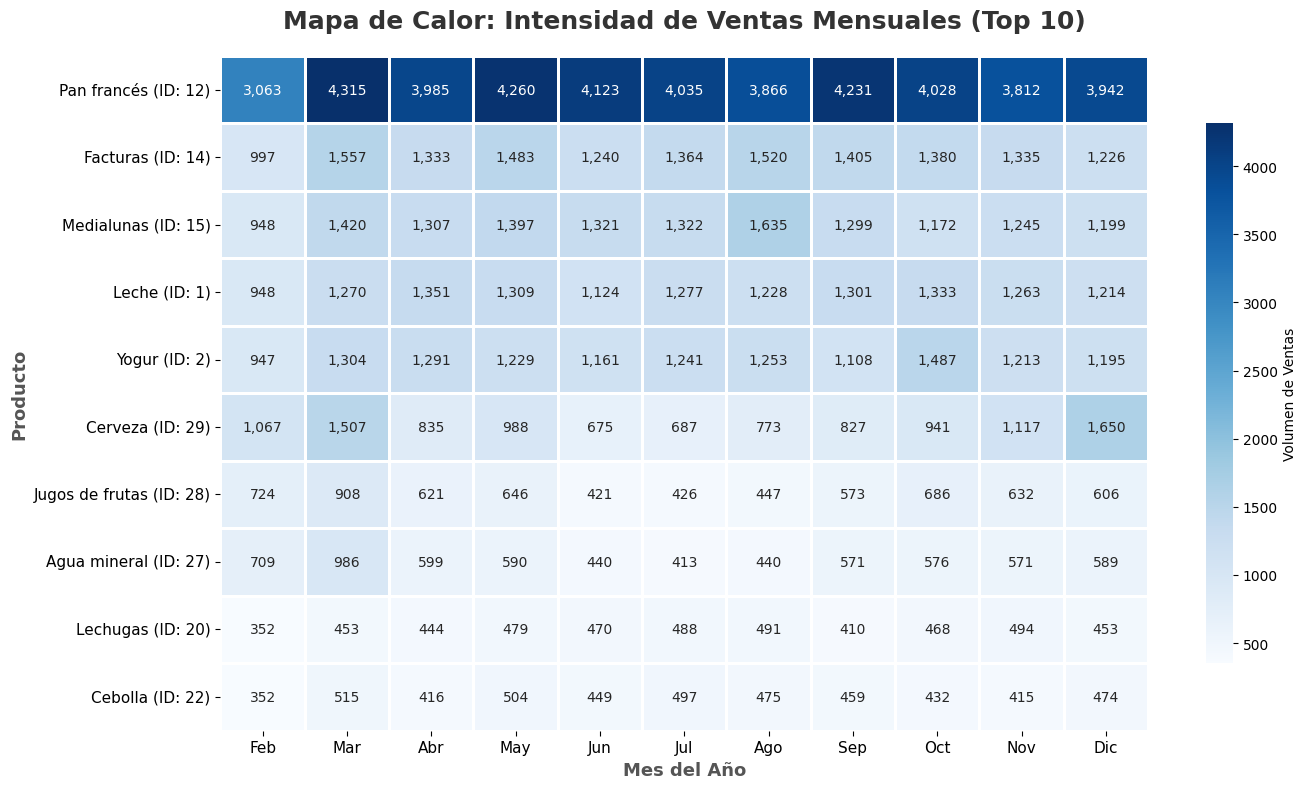

In [54]:
#Obtener el Top 10
top_10_ids = df_analisis.groupby('ID_Producto')['Cantidad'].sum().sort_values(ascending=False).head(10).index
df_analisis['Mes'] = df_analisis['Fecha_Venta'].dt.month
df_top_10 = df_analisis[df_analisis['ID_Producto'].isin(top_10_ids)]

# Agrupamos por Mes y por ID
tendencia_top10 = df_top_10.groupby(['Mes', 'ID_Producto'])['Cantidad'].sum().reset_index()
# Hacemos un merge (unión) con df_productos para traer la columna 'Nombre_producto'
tendencia_top10 = tendencia_top10.merge(df_productos[['ID_Producto', 'Nombre_producto']], on='ID_Producto', how='left')
#Unimos Nombre e ID para que la etiqueta sea súper clara
tendencia_top10['Etiqueta_Producto'] = tendencia_top10['Nombre_producto'] + ' (ID: ' + tendencia_top10['ID_Producto'].astype(str) + ')'
# Hacemos el pivot usando nuestra nueva 'Etiqueta_Producto' en lugar del ID
matriz_ventas = tendencia_top10.pivot(index='Etiqueta_Producto', columns='Mes', values='Cantidad')
matriz_ventas = matriz_ventas.fillna(0)

#Ordenamos la matriz por el total de ventas (de mayor a menor)
matriz_ventas['Total_Anual'] = matriz_ventas.sum(axis=1)
matriz_ventas = matriz_ventas.sort_values('Total_Anual', ascending=False).drop(columns='Total_Anual')
# Cambiamos los números de los meses por sus nombres
nombres_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
matriz_ventas.columns = [nombres_meses[m-1] for m in matriz_ventas.columns]

plt.figure(figsize=(14, 8))

sns.heatmap(matriz_ventas,
            cmap='Blues',
            annot=True,
            fmt=',.0f',
            linewidths=1,
            linecolor='white',
            cbar_kws={'label': 'Volumen de Ventas', 'shrink': 0.8})
plt.title('Mapa de Calor: Intensidad de Ventas Mensuales (Top 10)', fontsize=18, fontweight='bold', pad=20, color='#333333')
plt.xlabel('Mes del Año', fontsize=13, fontweight='bold', color='#555555')
plt.ylabel('Producto', fontsize=13, fontweight='bold', color='#555555')

plt.yticks(rotation=0, fontsize=11)
plt.xticks(fontsize=11)

plt.tight_layout()
plt.show()